In [1]:
cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import math
import os
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Sequence

from config.dataset_info import DATASET_INFO

import matplotlib.pyplot as plt
import torch


def locate_project_root(start: Path | None = None) -> Path:
    cursor = (start or Path.cwd()).resolve()
    for candidate in [cursor, *cursor.parents]:
        if (candidate / "data").exists() and (candidate / "test_notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root that contains both data/ and test_notebooks/.")


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eps = 1e-12
_AUTO_TOKENS = {"auto", "adaptive", "any", "*"}
_LEN_PATTERN = re.compile(r"_len_(\d+)_pfN_")
_PF_RESULT_PATTERN = re.compile(
    r"^pf_results_sigma_y_(?P<sigma>[^_]+)_batch_(?P<batch>\d+)_len_(?P<seq_len>\d+)_pfN_(?P<pf_N>\d+)_(?P<seed>\d+)(?P<obs_suffix>_[^.]+)?\.pt$"
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")


@dataclass
class ExperimentConfig:
    name: str
    dataset: str
    sigma_y: float | str | None
    input_len: int
    output_len: int | None = None
    obs_fn: str = "default"
    batch_size: int = 64
    dt: float = 0.15
    pf_N_list: Sequence[int] = field(default_factory=list)
    seed_list: Sequence[int] = field(default_factory=list)
    max_t_list: Sequence[int] = field(default_factory=list)
    len_candidates: Sequence[int] = field(default_factory=list)
    save_avg: bool = True
    verbose: bool = True

    def __post_init__(self) -> None:
        if self.output_len is None:
            self.output_len = self.input_len

    @property
    def data_dir(self) -> Path:
        return PROJECT_ROOT / "data" / self.dataset


def _is_auto_token(value: object) -> bool:
    return str(value or "").strip().lower() in _AUTO_TOKENS


def _sigma_aliases(sigma_y: float | str | None) -> list[str]:
    if sigma_y is None or _is_auto_token(sigma_y):
        return []

    raw = str(sigma_y).strip()
    aliases = {raw}
    try:
        sigma_float = float(raw)
        aliases.add(f"{sigma_float:.1f}")
        if sigma_float.is_integer():
            aliases.add(str(int(sigma_float)))
    except (TypeError, ValueError):
        pass
    return sorted(aliases)


def _default_sigma_str(sigma_y: float | str | None) -> str:
    if sigma_y is None or _is_auto_token(sigma_y):
        return "auto"
    try:
        return f"{float(sigma_y):.1f}"
    except (TypeError, ValueError):
        return str(sigma_y)


def _parse_len(path: Path) -> int | None:
    matched = _LEN_PATTERN.search(path.name)
    return int(matched.group(1)) if matched else None


def _default_obs_fn(dataset: str) -> str:
    cfg = DATASET_INFO.get(str(dataset).lower(), {})
    return str(cfg.get("obs_fn", "identity") or "identity").lower()


def _obs_suffix(cfg: ExperimentConfig) -> str | None:
    default_obs_fn = _default_obs_fn(cfg.dataset)
    obs_fn = str(cfg.obs_fn or "default").lower()
    if _is_auto_token(obs_fn):
        return None
    if obs_fn == "default":
        obs_fn = default_obs_fn
    return "" if obs_fn == default_obs_fn else f"_{obs_fn}"


def _build_file_name(sigma_str: str, batch_size: int, seq_len: int, pf_N: int, seed: int, obs_suffix: str = "") -> str:
    return f"pf_results_sigma_y_{sigma_str}_batch_{batch_size}_len_{seq_len}_pfN_{pf_N}_{seed}{obs_suffix}.pt"


def _parse_pf_result_file(path: Path) -> dict[str, object] | None:
    matched = _PF_RESULT_PATTERN.match(path.name)
    if matched is None:
        return None
    return {
        "sigma_str": matched.group("sigma"),
        "batch": int(matched.group("batch")),
        "seq_len": int(matched.group("seq_len")),
        "pf_N": int(matched.group("pf_N")),
        "seed": int(matched.group("seed")),
        "obs_suffix": matched.group("obs_suffix") or "",
    }


def resolve_seed_file(cfg: ExperimentConfig, pf_N: int, seed: int) -> tuple[Path | None, bool]:
    obs_suffix = _obs_suffix(cfg)
    sigma_opts = _sigma_aliases(cfg.sigma_y)
    len_opts = [cfg.input_len, *cfg.len_candidates]
    len_set = set(len_opts)

    pattern = f"pf_results_sigma_y_*_batch_{cfg.batch_size}_len_*_pfN_{pf_N}_*.pt"
    parsed_matches: list[tuple[Path, dict[str, object]]] = []
    for candidate in cfg.data_dir.glob(pattern):
        meta = _parse_pf_result_file(candidate)
        if meta is None:
            continue
        if meta["seed"] != seed:
            continue
        parsed_matches.append((candidate, meta))

    if not parsed_matches:
        return None, False

    # obs_fn matching: explicit obs_fn is strict; auto mode allows unique suffix only.
    if obs_suffix is not None:
        obs_matches = [item for item in parsed_matches if item[1]["obs_suffix"] == obs_suffix]
        if not obs_matches:
            return None, False
    else:
        obs_values = {item[1]["obs_suffix"] for item in parsed_matches}
        if len(obs_values) > 1:
            if cfg.verbose:
                print(
                    f"pf_N={pf_N}, seed={seed}: multiple obs suffix {sorted(obs_values)} in auto mode; set obs_fn explicitly."
                )
            return None, False
        obs_matches = parsed_matches

    # sigma_y matching: explicit sigma first; if not found, fallback to unique sigma only.
    sigma_matches = obs_matches
    if sigma_opts:
        explicit_sigma = [item for item in obs_matches if item[1]["sigma_str"] in sigma_opts]
        if explicit_sigma:
            sigma_matches = explicit_sigma
        else:
            sigma_values = {item[1]["sigma_str"] for item in obs_matches}
            if len(sigma_values) != 1:
                if cfg.verbose:
                    print(
                        f"pf_N={pf_N}, seed={seed}: ambiguous sigma_y {sorted(sigma_values)}, set sigma_y explicitly."
                    )
                return None, False
            if cfg.verbose:
                wanted_sigma = cfg.sigma_y
                auto_sigma = next(iter(sigma_values))
                print(
                    f"pf_N={pf_N}, seed={seed}: sigma_y={wanted_sigma} not found; auto-used {auto_sigma}."
                )
    else:
        sigma_values = {item[1]["sigma_str"] for item in obs_matches}
        if len(sigma_values) > 1:
            if cfg.verbose:
                print(
                    f"pf_N={pf_N}, seed={seed}: multiple sigma_y {sorted(sigma_values)} in auto mode; set sigma_y explicitly."
                )
            return None, False

    # Prefer configured lengths; then nearest available length.
    strict_len = [item for item in sigma_matches if item[1]["seq_len"] in len_set]
    ranked_source = strict_len or sigma_matches
    ranked = sorted(
        ranked_source,
        key=lambda item: (
            0 if item[1]["seq_len"] == cfg.input_len else 1,
            abs(item[1]["seq_len"] - cfg.input_len),
            0 if item[1]["seq_len"] in len_set else 1,
            item[0].name,
        ),
    )

    best_path, best_meta = ranked[0]
    used_len_fallback = best_meta["seq_len"] != cfg.input_len
    return best_path, used_len_fallback


def load_mean_cov(file_path: Path, map_to_device: torch.device) -> tuple[torch.Tensor, torch.Tensor]:
    data = torch.load(file_path, weights_only=True, map_location=map_to_device)
    entry = data[0]

    mean = entry.get("means") if isinstance(entry, dict) else None
    cov = entry.get("covs") if isinstance(entry, dict) else None

    if mean is None and isinstance(entry, dict):
        mean = entry.get("post_means")
    if cov is None and isinstance(entry, dict):
        cov = entry.get("post_covs")

    if mean is None or cov is None:
        raise KeyError(f"Missing mean/cov keys in {file_path.name}")

    return mean, cov





Project root: /home/bhchen/LearnKalmanGain
Device: cuda


In [3]:
def compute_ci_metrics(mean_tensor: torch.Tensor, cov_tensor: torch.Tensor, max_t: int, eps_value: float = 1e-12) -> dict[str, float]:
    n_seeds = mean_tensor.shape[0]
    if n_seeds < 2:
        return {
            "se_rmse_mean": float("nan"),
            "se_rrmse_mean": float("nan"),
            "se_f2_cov": float("nan"),
            "se_rf2_cov": float("nan"),
        }

    max_t_eff = min(max_t, mean_tensor.shape[1], cov_tensor.shape[1])
    mean_t = mean_tensor[:, :max_t_eff]
    cov_t = cov_tensor[:, :max_t_eff]

    avg_mean = torch.mean(mean_t, dim=0, keepdim=True)
    error_mean = mean_t - avg_mean
    std_mean = torch.sqrt(torch.sum(error_mean ** 2, dim=0) / (n_seeds - 1))
    se_mean = std_mean / math.sqrt(n_seeds)
    ci95_mean = 1.96 * se_mean

    ci95_rmse = torch.sqrt(torch.mean(ci95_mean ** 2, dim=-1))
    se_rmse_mean = ci95_rmse.mean().item()

    mean_scale = torch.sqrt(torch.mean(avg_mean.squeeze(0) ** 2, dim=-1))
    se_rrmse_mean = (ci95_rmse / (mean_scale + eps_value)).mean().item()

    avg_cov = torch.mean(cov_t, dim=0, keepdim=True)
    error_cov = cov_t - avg_cov
    std_cov = torch.sqrt(torch.sum(error_cov ** 2, dim=0) / (n_seeds - 1))
    se_cov = std_cov / math.sqrt(n_seeds)
    ci95_cov = 1.96 * se_cov

    ci95_cov_fro = torch.linalg.norm(ci95_cov, ord="fro", dim=(-2, -1))
    se_f2_cov = ci95_cov_fro.mean().item()

    cov_scale = torch.linalg.norm(avg_cov.squeeze(0), ord="fro", dim=(-2, -1))
    se_rf2_cov = (ci95_cov_fro / (cov_scale + eps_value)).mean().item()

    return {
        "se_rmse_mean": se_rmse_mean,
        "se_rrmse_mean": se_rrmse_mean,
        "se_f2_cov": se_f2_cov,
        "se_rf2_cov": se_rf2_cov,
    }


def _save_avg_file(
    cfg: ExperimentConfig,
    pf_N: int,
    mean_tensor: torch.Tensor,
    cov_tensor: torch.Tensor,
    sigma_str: str | None = None,
    obs_suffix: str | None = None,
) -> Path:
    cfg.data_dir.mkdir(parents=True, exist_ok=True)
    if sigma_str is None:
        sigma_str = _default_sigma_str(cfg.sigma_y)

    if obs_suffix is None:
        resolved_obs_suffix = _obs_suffix(cfg)
        obs_suffix = resolved_obs_suffix or ""

    out_file = cfg.data_dir / (
        f"pf_results_sigma_y_{sigma_str}_batch_{cfg.batch_size}_len_{cfg.output_len}_pfN_{pf_N}_avg{obs_suffix}.pt"
    )
    torch.save([{"means": mean_tensor.mean(dim=0), "covs": cov_tensor.mean(dim=0)}], out_file)
    return out_file


def _plot_experiment(
    cfg: ExperimentConfig,
    metrics_by_t: dict[int, dict[str, list[float]]],
    pf_N_axis: Sequence[int] | None = None,
) -> None:
    pf_N_axis = list(pf_N_axis or cfg.pf_N_list)
    if not pf_N_axis:
        print("No available pf_N to plot.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plot_items = [
        (0, 0, "se_rmse_mean", "SE of mean (RMSE, 95% CI)"),
        (0, 1, "se_f2_cov", "SE of cov (F-norm, 95% CI)"),
        (1, 0, "se_rrmse_mean", "SE of mean (RRMSE, 95% CI)"),
        (1, 1, "se_rf2_cov", "SE of cov (RF2, 95% CI)"),
    ]

    for max_t, metric_dict in metrics_by_t.items():
        label = fr"T={max_t * cfg.dt:.2f} ($\Delta t$={cfg.dt})"
        for r, c, key, ylabel in plot_items:
            ax = axes[r, c]
            ax.plot(pf_N_axis, metric_dict[key], marker="o", linestyle="-", label=label)
            ax.set_xscale("log")
            ax.set_xlabel("number of particles")
            ax.set_ylabel(ylabel)
            ax.grid(True, which="both", ls="--")

    fig.suptitle(cfg.name)
    for ax in axes.flatten():
        ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


def run_experiment(cfg: ExperimentConfig, map_to_device: torch.device = device, eps_value: float = eps) -> dict:
    print(f"\n=== {cfg.name} ===")
    print(f"Data dir: {cfg.data_dir}")

    per_pf_data: dict[int, dict[str, object]] = {}
    missing_pf_N: list[int] = []

    for pf_N in cfg.pf_N_list:
        mean_list: list[torch.Tensor] = []
        cov_list: list[torch.Tensor] = []
        missing_seeds: list[int] = []
        failed_seeds: list[int] = []
        fallback_files: list[str] = []
        loaded_sigma_values: set[str] = set()
        loaded_sigma_counts: dict[str, int] = {}
        loaded_obs_suffix_values: set[str] = set()

        for seed in cfg.seed_list:
            file_path, used_fallback = resolve_seed_file(cfg, pf_N, seed)
            if file_path is None:
                missing_seeds.append(seed)
                continue

            try:
                mean_tensor, cov_tensor = load_mean_cov(file_path, map_to_device)
                mean_list.append(mean_tensor)
                cov_list.append(cov_tensor)

                file_meta = _parse_pf_result_file(file_path)
                if file_meta is not None:
                    sigma_token = str(file_meta["sigma_str"])
                    loaded_sigma_values.add(sigma_token)
                    loaded_sigma_counts[sigma_token] = loaded_sigma_counts.get(sigma_token, 0) + 1
                    loaded_obs_suffix_values.add(str(file_meta["obs_suffix"]))

                if used_fallback:
                    fallback_files.append(file_path.name)
            except Exception as exc:
                failed_seeds.append(seed)
                print(f"Could not load {file_path}: {exc}")

        if not mean_list:
            missing_pf_N.append(pf_N)
            print(f"pf_N={pf_N}: no usable files, skipped.")
            if missing_seeds:
                print(f"  missing seeds ({len(missing_seeds)}): {missing_seeds}")
            if failed_seeds:
                print(f"  failed seeds ({len(failed_seeds)}): {failed_seeds}")
            continue

        mean_tensor = torch.stack(mean_list)
        cov_tensor = torch.stack(cov_list)

        if cfg.verbose and len(loaded_sigma_values) > 1:
            print(f"pf_N={pf_N}: multiple sigma_y matched {sorted(loaded_sigma_values)}")
        if cfg.verbose and len(loaded_obs_suffix_values) > 1:
            print(f"pf_N={pf_N}: multiple obs suffix matched {sorted(loaded_obs_suffix_values)}")

        cfg_sigma_str = _default_sigma_str(cfg.sigma_y)
        non_cfg_sigma_values = sorted([s for s in loaded_sigma_values if s != cfg_sigma_str])

        if len(loaded_sigma_values) == 1:
            resolved_sigma_str = next(iter(loaded_sigma_values))
        elif len(non_cfg_sigma_values) == 1:
            # If exactly one non-default sigma is observed, save avg using that matched sigma.
            resolved_sigma_str = non_cfg_sigma_values[0]
        else:
            ranked_sigma = sorted(loaded_sigma_counts.items(), key=lambda x: (-x[1], x[0]))
            if len(ranked_sigma) >= 2 and ranked_sigma[0][1] == ranked_sigma[1][1]:
                resolved_sigma_str = None
            else:
                resolved_sigma_str = ranked_sigma[0][0] if ranked_sigma else None

        resolved_obs_suffix = next(iter(loaded_obs_suffix_values)) if len(loaded_obs_suffix_values) == 1 else None

        if cfg.save_avg:
            avg_file = _save_avg_file(
                cfg,
                pf_N,
                mean_tensor,
                cov_tensor,
                sigma_str=resolved_sigma_str,
                obs_suffix=resolved_obs_suffix,
            )
            if cfg.verbose:
                print(f"Saved avg: {avg_file.name}")

        if cfg.verbose:
            print(
                f"pf_N={pf_N}: loaded {len(mean_list)}/{len(cfg.seed_list)} seeds, "
                f"missing {len(missing_seeds)}, failed {len(failed_seeds)}"
            )
            if missing_seeds:
                print(f"  missing seed ids: {missing_seeds}")
            if failed_seeds:
                print(f"  failed seed ids: {failed_seeds}")
            if fallback_files:
                print(f"  used len fallback for {len(fallback_files)} files")

        per_pf_data[pf_N] = {
            "mean_tensor": mean_tensor,
            "cov_tensor": cov_tensor,
            "n_loaded": len(mean_list),
            "missing_seeds": missing_seeds,
            "failed_seeds": failed_seeds,
            "fallback_files": fallback_files,
            "resolved_sigma_values": sorted(loaded_sigma_values),
            "resolved_obs_suffix_values": sorted(loaded_obs_suffix_values),
        }

    available_pf_N = [pf_N for pf_N in cfg.pf_N_list if pf_N in per_pf_data]
    print(f"Available pf_N: {available_pf_N}")
    if missing_pf_N:
        print(f"Missing pf_N (all seeds missing/failed): {missing_pf_N}")

    metrics_by_t: dict[int, dict[str, list[float]]] = {}
    for max_t in cfg.max_t_list:
        stats = {
            "se_rmse_mean": [],
            "se_rrmse_mean": [],
            "se_f2_cov": [],
            "se_rf2_cov": [],
        }
        for pf_N in available_pf_N:
            run_data = per_pf_data[pf_N]
            metric = compute_ci_metrics(
                run_data["mean_tensor"],
                run_data["cov_tensor"],
                max_t=max_t,
                eps_value=eps_value,
            )
            for key in stats:
                stats[key].append(metric[key])

        metrics_by_t[max_t] = stats

    _plot_experiment(cfg, metrics_by_t, pf_N_axis=available_pf_N)
    return {
        "config": cfg,
        "per_pf_data": per_pf_data,
        "metrics_by_t": metrics_by_t,
        "available_pf_N": available_pf_N,
        "missing_pf_N": missing_pf_N,
    }




In [4]:
COMMON_PF_N = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
COMMON_MAX_T = [100, 300, 500]
SEEDS_11 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
SEEDS_12 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 42]
SEEDS_100 = list(range(100))

EXPERIMENTS = {
    "lorenz63_sigma_1.0": ExperimentConfig(
        name="Lorenz63 (sigma_y=1.0)",
        dataset="lorenz63",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=COMMON_MAX_T,
    ),
    "lorenz63_sigma_1.0_square": ExperimentConfig(
        name="Lorenz63 (sigma_y=1.0)",
        dataset="lorenz63",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=COMMON_MAX_T,
        obs_fn="square",
    ),
    "rossler_sigma_1.0": ExperimentConfig(
        name="Rossler (sigma_y=1.0)",
        dataset="rossler",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=[1000, 2000, 5000, 10000, 20000, 50000, 100000],
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "lorenz96_sigma_1.0": ExperimentConfig(
        name="Lorenz96 (sigma_y=1.0)",
        dataset="lorenz96",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "circle_sigma_1.0": ExperimentConfig(
        name="Circle (sigma_y=1.0)",
        dataset="circle",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "hdoublewell_sigma_1.0": ExperimentConfig(
        name="HDoublewell (sigma_y=1.0)",
        dataset="Hdoublewell",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "doubling1d_sigma_0.1": ExperimentConfig(
        name="Doubling1D (sigma_y=0.1)",
        dataset="doubling1d",
        sigma_y=0.2,
        input_len=200,
        output_len=200,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=[100, 200],
        len_candidates=[500],
    ),
    "complex2d_sigma_0.1": ExperimentConfig(
        name="Complex2D (sigma_y=0.1)",
        dataset="complex2d",
        sigma_y=0.2,
        input_len=200,
        output_len=200,
        pf_N_list=[500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000],
        seed_list=SEEDS_12,
        max_t_list=[100, 200],
    ),
}

print("Available experiment keys:")
for key in EXPERIMENTS:
    print(f"- {key}")


Available experiment keys:
- lorenz63_sigma_1.0
- lorenz63_sigma_1.0_square
- rossler_sigma_1.0
- lorenz96_sigma_1.0
- circle_sigma_1.0
- hdoublewell_sigma_1.0
- doubling1d_sigma_0.1
- complex2d_sigma_0.1



=== Lorenz63 (sigma_y=1.0) ===
Data dir: /home/bhchen/LearnKalmanGain/data/lorenz63
pf_N=1000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=2000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=5000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=10000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=20000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=50000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=100000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=200000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=500000: no usable files, skipped.
  missing seeds (11): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
pf_N=1000000, seed=42: sigma_y=1.0 not found; auto-used 16.9

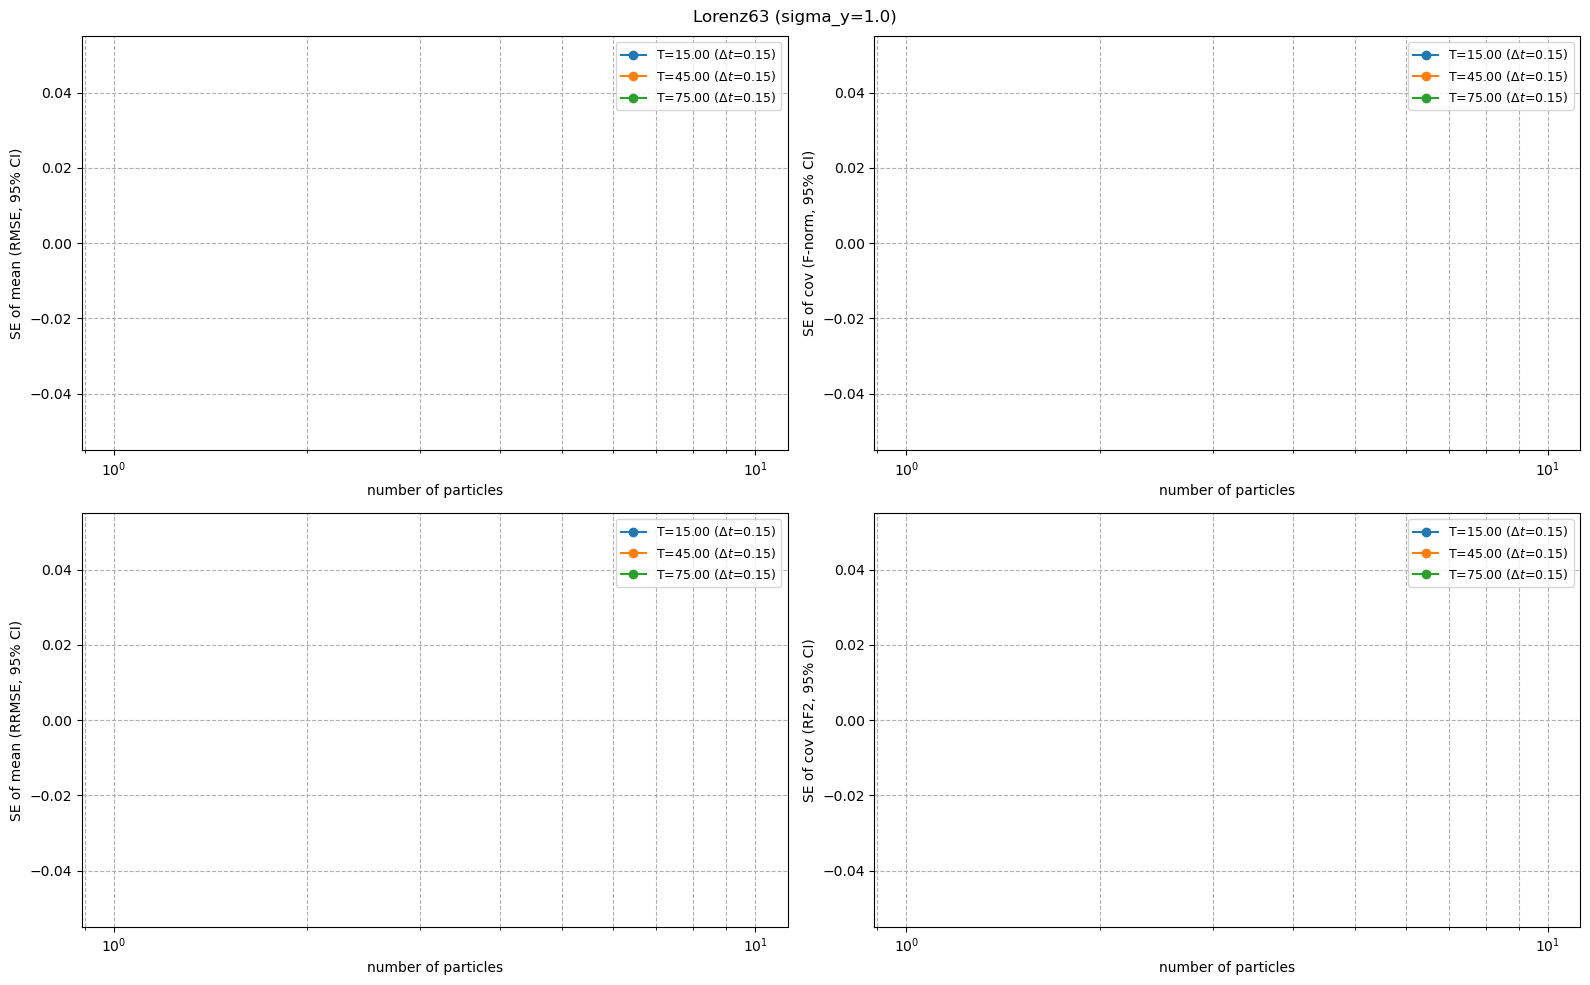


Done. Results stored in `results`.


In [5]:
SELECTED_EXPERIMENTS = [
    # "lorenz63_sigma_1.0",
    "lorenz63_sigma_1.0_square",
    # "rossler_sigma_1.0",
    # "lorenz96_sigma_1.0",
    # "circle_sigma_1.0",
    # "hdoublewell_sigma_1.0",
    # "doubling1d_sigma_0.1",
    # "complex2d_sigma_0.1",
]

results = {}
for exp_key in SELECTED_EXPERIMENTS:
    cfg = EXPERIMENTS[exp_key]
    results[exp_key] = run_experiment(cfg)

print("\nDone. Results stored in `results`.")
